In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [3]:
df = pd.read_csv("../datasets/samsung.csv")

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nInformación del dataset:")
df.info()

Dimensiones del dataset: (2850, 3)

Primeras filas:


,Date,Close,Volume
0,02/01/2008,10880,18047200
1,03/01/2008,10920,19346500
2,04/01/2008,10780,17997350
3,07/01/2008,10380,39787200
4,08/01/2008,10320,24783700



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    2850 non-null   str  
 1   Close   2850 non-null   int64
 2   Volume  2850 non-null   int64
dtypes: int64(2), str(1)
memory usage: 66.9 KB


In [4]:
print("Valores faltantes:")
print(df.isnull().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

Valores faltantes:
Date      0
Close     0
Volume    0
dtype: int64

Filas duplicadas:
0


In [5]:
print(df.describe())

              Close        Volume
count   2850.000000  2.850000e+03
mean   26611.305263  1.610505e+07
std    11991.608543  8.661794e+06
min     8040.000000  0.000000e+00
25%    16300.000000  1.021426e+07
50%    25600.000000  1.359033e+07
75%    30850.000000  1.960970e+07
max    57220.000000  6.487345e+07


In [6]:
print(df.dtypes)

Date        str
Close     int64
Volume    int64
dtype: object


In [7]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df.dtypes)

Date      datetime64[us]
Close              int64
Volume             int64
dtype: object


In [8]:
X = df[["Close", "Volume"]].copy()

print("Forma de X:", X.shape)
print("\nPrimeras filas de X:")
display(X.head())

Forma de X: (2850, 2)

Primeras filas de X:


,Close,Volume
0,10880,18047200
1,10920,19346500
2,10780,17997350
3,10380,39787200
4,10320,24783700


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Forma de los datos escalados:", X_scaled.shape)

Forma de los datos escalados: (2850, 2)


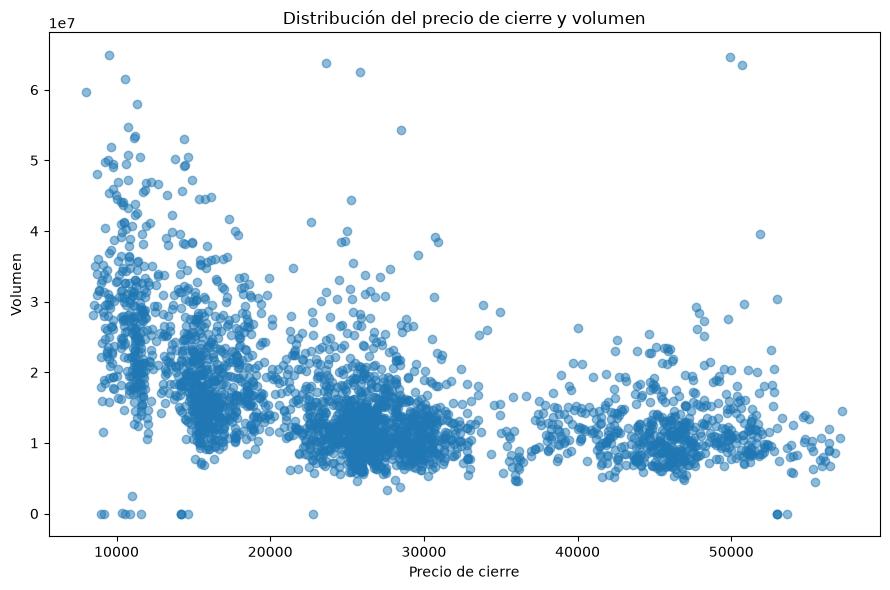

In [12]:
# Visualización inicial de las variables utilizadas para clustering
plt.figure(figsize=(9, 6))

plt.scatter(
    X["Close"],
    X["Volume"],
    alpha=0.5
)

plt.title("Distribución del precio de cierre y volumen")
plt.xlabel("Precio de cierre")
plt.ylabel("Volumen")
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
k_values = range(2, 11)

silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )
    
    calinski_scores.append(
        calinski_harabasz_score(X_scaled, labels)
    )
    
    davies_scores.append(
        davies_bouldin_score(X_scaled, labels)
    )

resultados_k = pd.DataFrame({
    "k": list(k_values),
    "Silhouette": silhouette_scores,
    "Calinski-Harabasz": calinski_scores,
    "Davies-Bouldin": davies_scores
})

resultados_k

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.446086,2635.676392,0.879193
1,3,0.501259,3520.656094,0.685211
2,4,0.477436,3787.421231,0.716542
3,5,0.460161,3705.369900,0.744155
4,6,0.455241,3556.608696,0.738504
5,7,0.432140,3461.408466,0.816446
6,8,0.427130,3508.157732,0.798487
7,9,0.402068,3440.853762,0.826916
8,10,0.378677,3378.565734,0.838841


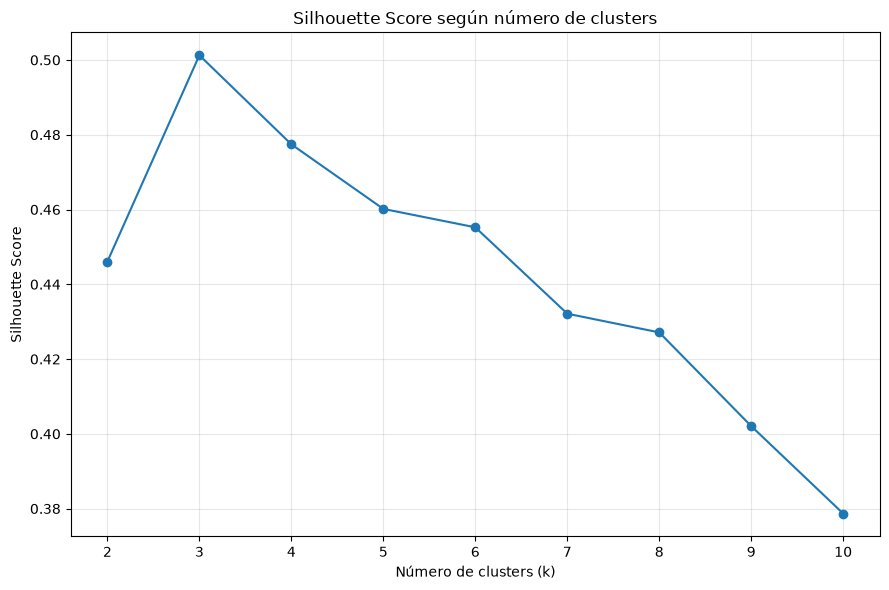

In [14]:
plt.figure(figsize=(9, 6))

plt.plot(
    resultados_k["k"],
    resultados_k["Silhouette"],
    marker="o"
)

plt.title("Silhouette Score según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

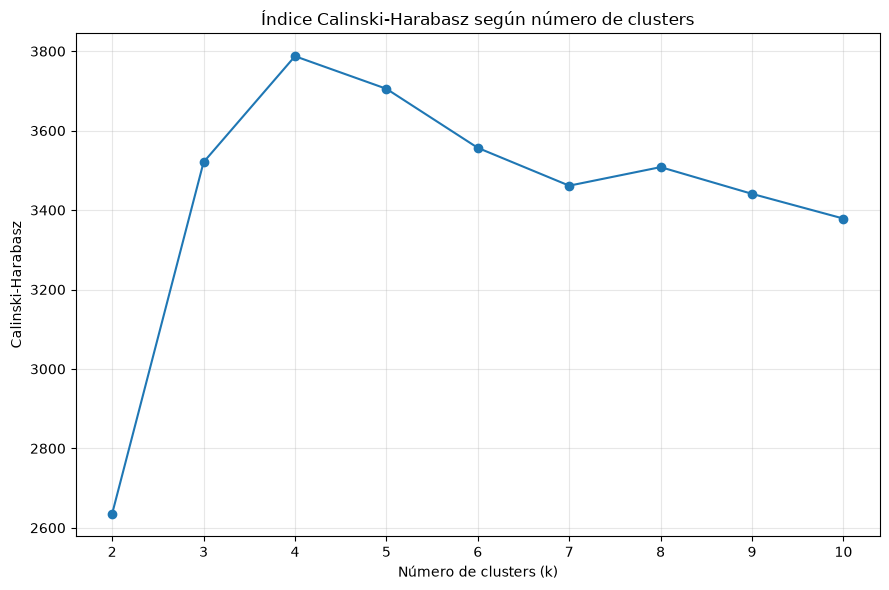

In [15]:
plt.figure(figsize=(9, 6))

plt.plot(
    resultados_k["k"],
    resultados_k["Calinski-Harabasz"],
    marker="o"
)

plt.title("Índice Calinski-Harabasz según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Calinski-Harabasz")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_calinski_harabasz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

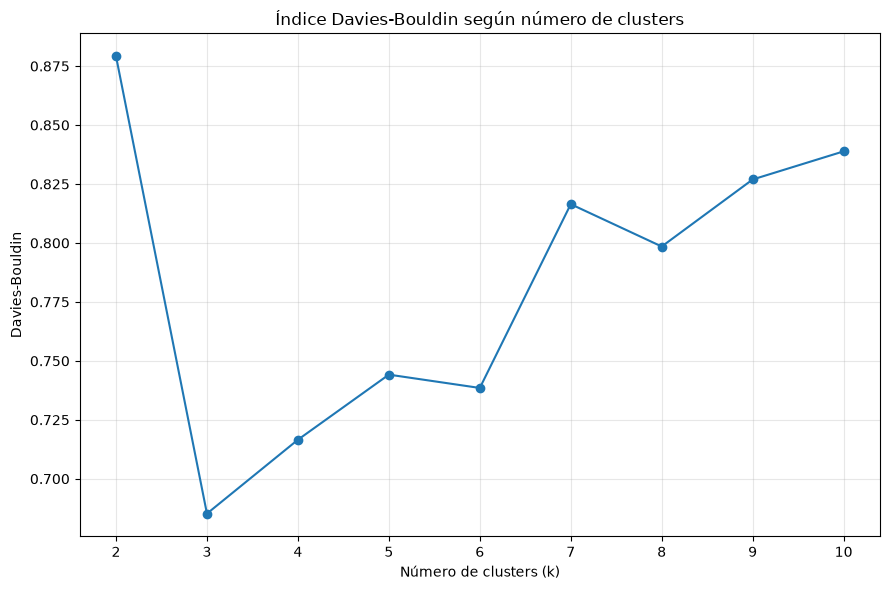

In [16]:
plt.figure(figsize=(9, 6))

plt.plot(
    resultados_k["k"],
    resultados_k["Davies-Bouldin"],
    marker="o"
)

plt.title("Índice Davies-Bouldin según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_davies_bouldin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Modelo final de K-Means
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

print("Centros de los clusters:")
print(kmeans_final.cluster_centers_)

Centros de los clusters:
[[-0.24360041 -0.38313089]
 [ 1.60323879 -0.5144436 ]
 [-0.96498584  1.47972552]]


In [18]:
# Agregar el cluster asignado a cada observación
df["Cluster"] = clusters

print(df[["Date", "Close", "Volume", "Cluster"]].head(10))

        Date  Close    Volume  Cluster
0 2008-01-02  10880  18047200        0
1 2008-01-03  10920  19346500        2
2 2008-01-04  10780  17997350        0
3 2008-01-07  10380  39787200        2
4 2008-01-08  10320  24783700        2
5 2008-01-09  10500  23865450        2
6 2008-01-10  10320  31551350        2
7 2008-01-11  10320  23425150        2
8 2008-01-14  10500  22167000        2
9 2008-01-15  10640  40283950        2


In [19]:
# Métricas del modelo final
silhouette_final = silhouette_score(X_scaled, clusters)
calinski_final = calinski_harabasz_score(X_scaled, clusters)
davies_final = davies_bouldin_score(X_scaled, clusters)

print("Métricas del modelo final:")
print(f"Silhouette Score:       {silhouette_final:.4f}")
print(f"Calinski-Harabasz:      {calinski_final:.4f}")
print(f"Davies-Bouldin:         {davies_final:.4f}")

Métricas del modelo final:
Silhouette Score:       0.5013
Calinski-Harabasz:      3520.6561
Davies-Bouldin:         0.6852


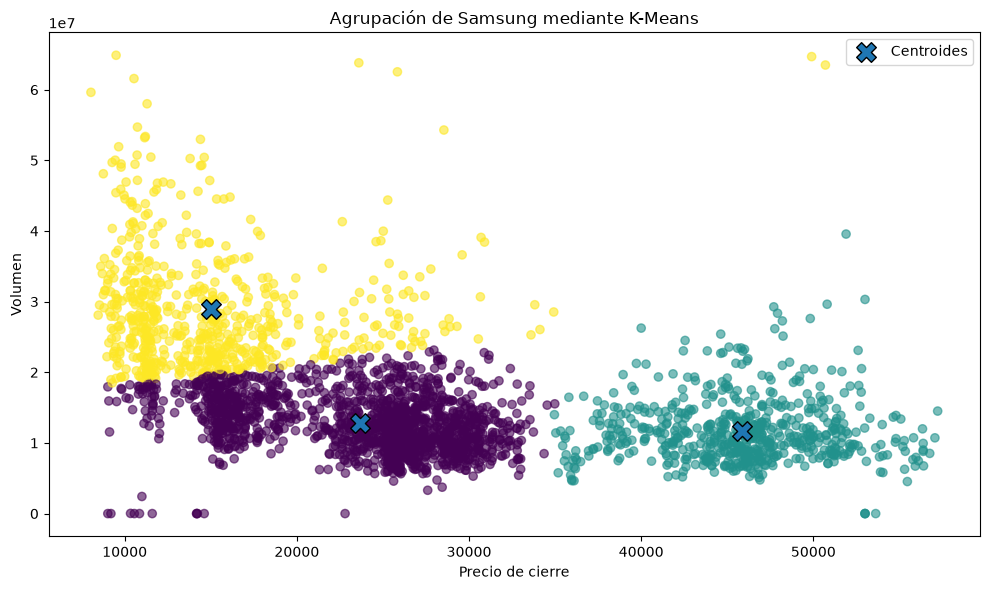

In [20]:
# Visualización de los clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    X["Close"],
    X["Volume"],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

# Centros de los clusters en la escala original
centers_original = scaler.inverse_transform(
    kmeans_final.cluster_centers_
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=200,
    edgecolors="black",
    label="Centroides"
)

plt.title("Agrupación de Samsung mediante K-Means")
plt.xlabel("Precio de cierre")
plt.ylabel("Volumen")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Estadísticas de cada cluster
cluster_summary = df.groupby("Cluster")[["Close", "Volume"]].agg(
    ["count", "mean", "std", "min", "max"]
)

cluster_summary

Close                                          Volume                \
        count          mean          std    min    max  count          mean   
Cluster                                                                       
0        1597  23695.510332  5567.976718   9020  34980   1597  1.278258e+07   
1         622  45833.344051  4676.720303  34960  57220    622  1.164983e+07   
2         631  15043.026941  5459.585850   8040  50700    631  2.890558e+07   

                                           
                  std       min       max  
Cluster                                    
0        3.901727e+06         0  23142150  
1        4.551597e+06         0  39565391  
2        8.282937e+06  18496050  64873450

In [22]:
# Promedios por cluster
cluster_means = df.groupby("Cluster")[["Close", "Volume"]].mean()

cluster_means

,Close,Volume
Cluster,,
0,23695.510332,1.278258e+07
1,45833.344051,1.164983e+07
2,15043.026941,2.890558e+07


In [23]:
# Cantidad de observaciones en cada cluster
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Observaciones por cluster:")
print(cluster_counts)

Observaciones por cluster:
Cluster
0    1597
1     622
2     631
Name: count, dtype: int64


In [24]:
from sklearn.pipeline import Pipeline
import joblib
import os

# Pipeline final: estandarización + K-Means
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ))
])

# Entrenar el pipeline con los datos originales
final_pipeline.fit(X)

print("Pipeline final entrenado correctamente.")

Pipeline final entrenado correctamente.


In [26]:
os.makedirs("../models/clustering", exist_ok=True)

model_path = "../models/clustering/samsung_kmeans.joblib"

joblib.dump(final_pipeline, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ../models/clustering/samsung_kmeans.joblib


In [28]:
# Cargar nuevamente el modelo
loaded_model = joblib.load(model_path)

print("Modelo cargado correctamente.")
print(loaded_model)

Modelo cargado correctamente.
Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])


In [29]:
# Verificar predicciones del modelo cargado
clusters_loaded = loaded_model.predict(X)

print("¿Las asignaciones coinciden con el modelo original?")
print(np.array_equal(clusters, clusters_loaded))

¿Las asignaciones coinciden con el modelo original?
True


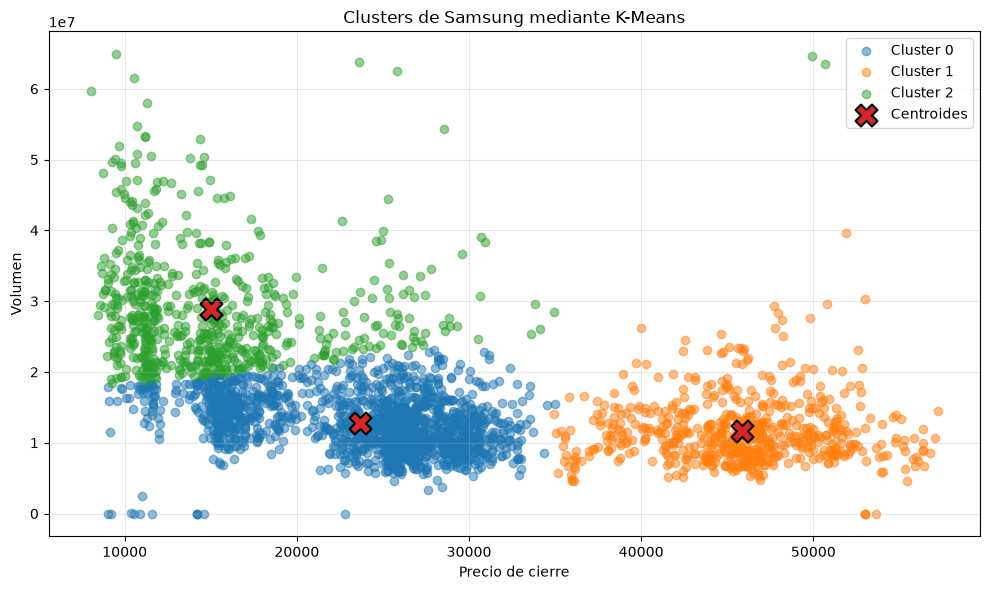

In [30]:
# Obtener centros de los clusters en escala original
centers_original = scaler.inverse_transform(
    kmeans_final.cluster_centers_
)

plt.figure(figsize=(10, 6))

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    
    plt.scatter(
        cluster_data["Close"],
        cluster_data["Volume"],
        alpha=0.5,
        label=f"Cluster {cluster_id}"
    )

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroides"
)

plt.title("Clusters de Samsung mediante K-Means")
plt.xlabel("Precio de cierre")
plt.ylabel("Volumen")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/samsung_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()